In [ ]:
# %% [markdown]
# # 02. Calidad, Limpieza y Preparación de Datos
# En este notebook se aplican decisiones justificadas con la evidencia obtenida en la inspección.

# %%
import os
import pandas as pd

# 1. Buscador inteligente de rutas para el dataset crudo (evita FileNotFoundError)
posibles_rutas = [
    '../data/raw/reporte_clinica.csv',
    '../data/raw/reporte_clinica (3).csv',
    'data/raw/reporte_clinica.csv',
    'data/raw/reporte_clinica (3).csv',
    'reporte_clinica (3).csv'
]

df = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta, index_col=0)
        print(f"✅ ¡Dataset original cargado con éxito desde: {ruta}!")
        break

if df is None:
    raise FileNotFoundError("❌ No se encontró el archivo original. Verifica que esté en la carpeta del proyecto.")

# Guardamos el total inicial de filas para calcular la retención más adelante
total_inicial = len(df)

# %%
# 2. ASEGURAR QUE EXISTAN LAS CARPETAS DE DESTINO
# Esto evita errores al intentar guardar el archivo final y el log
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('../logs', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# %%
# 3. PROCESAMIENTO Y LIMPIEZA DE DATOS (Basado en evidencia)

# Paso A: Estandarizar la columna 'smoker'
# Evidencia: Había mezcla de 'yes', 'no' y 'No'
df['smoker'] = df['smoker'].str.lower()

# Paso B: Estandarizar la columna 'region'
# Evidencia: Se encontró la sigla 'SE' en lugar de 'southeast'
df['region'] = df['region'].replace({'SE': 'southeast'})

# Paso C: Eliminación de duplicados físicos
df = df.drop_duplicates()

# %%
# 4. CALCULAR MÉTRICAS PARA EL LOG ETL
filas_finales = len(df)
nulos_finales = df.isnull().sum().sum()
retencion = (filas_finales / total_inicial) * 100

print("\n--- Resumen del Pipeline ---")
print(f"Filas Iniciales: {total_inicial}")
print(f"Filas Finales: {filas_finales}")
print(f"Porcentaje de Retención: {retencion:.2f}%")

# %%
# 5. GUARDAR EL DATASET PROCESADO Y EL LOG EN LAS RUTAS CORRECTAS

# Definir rutas de guardado cruzadas (por si ejecutas desde la raíz o desde notebooks)
ruta_processed = '../data/processed/reporte_clinica_procesado.csv' if os.path.exists('../data') else 'data/processed/reporte_clinica_procesado.csv'
ruta_log = '../logs/pipeline_log.csv' if os.path.exists('../logs') else 'logs/pipeline_log.csv'

# Guardar dataset limpio
df.to_csv(ruta_processed, index=False)
print(f"✅ Dataset procesado guardado en: {ruta_processed}")

# Crear y guardar el DataFrame del Log ETL estructurado según la rúbrica
log_df = pd.DataFrame([{
    "Paso": "1",
    "Descripción": "Estandarización de smoker/region y remoción de duplicados.",
    "Filas": filas_finales,
    "Nulos": nulos_finales,
    "Retención (%)": round(retencion, 2)
}])

log_df.to_csv(ruta_log, index=False)
print(f"✅ Log ETL generado con éxito en: {ruta_log}")

✅ ¡Dataset original cargado con éxito desde: reporte_clinica (3).csv!

--- Resumen del Pipeline ---
Filas Iniciales: 1363
Filas Finales: 1337
Porcentaje de Retención: 98.09%
✅ Dataset procesado guardado en: ../data/processed/reporte_clinica_procesado.csv
✅ Log ETL generado con éxito en: ../logs/pipeline_log.csv


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid")

# Carga inteligente de datos
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Datos cargados correctamente para graficar.")
        break

✅ Datos cargados correctamente para graficar.


Gráfico 1: Histograma de Costos Médicos

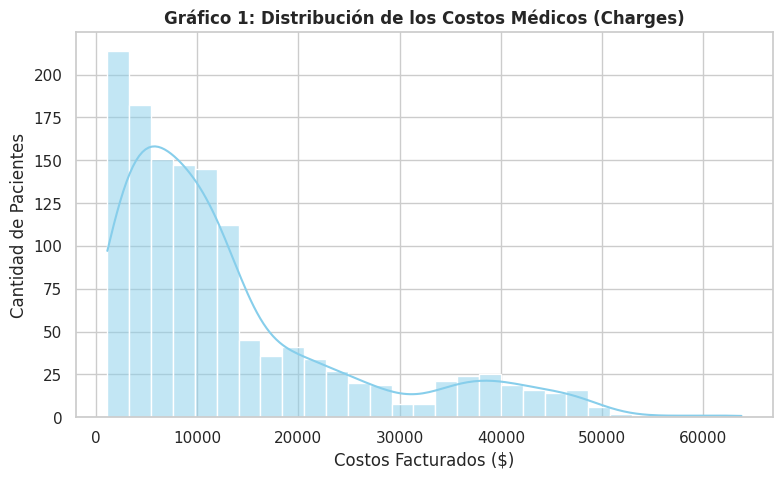

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='charges', kde=True, color='skyblue')

plt.title('Gráfico 1: Distribución de los Costos Médicos (Charges)', fontsize=12, fontweight='bold')
plt.xlabel('Costos Facturados ($)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

Gráfico 2: Diagrama de Caja del IMC

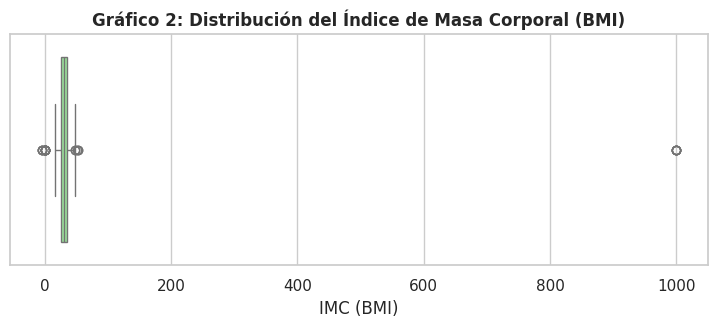

In [ ]:
plt.figure(figsize=(9, 3))
sns.boxplot(data=df, x='bmi', color='lightgreen')

plt.title('Gráfico 2: Distribución del Índice de Masa Corporal (BMI)', fontsize=12, fontweight='bold')
plt.xlabel('IMC (BMI)')
plt.show()

Gráfico 3: Costos según si es Fumador

/tmp/ipykernel_19873/89764504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')


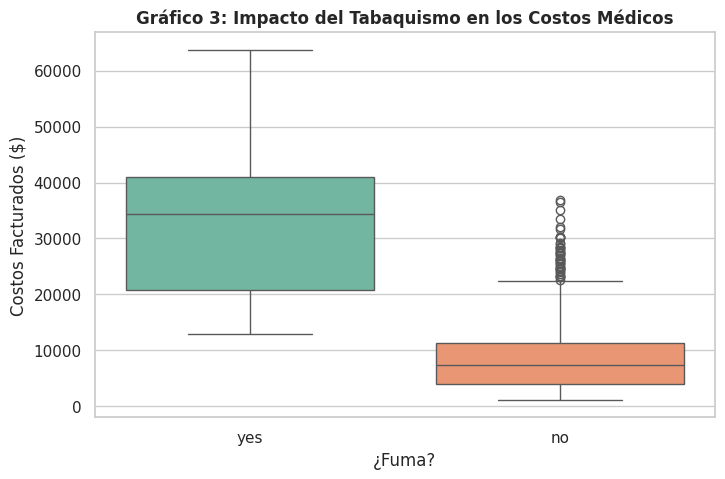

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')

plt.title('Gráfico 3: Impacto del Tabaquismo en los Costos Médicos', fontsize=12, fontweight='bold')
plt.xlabel('¿Fuma?')
plt.ylabel('Costos Facturados ($)')
plt.show()

Gráfico 4: Dispersión de Edad vs. Costos

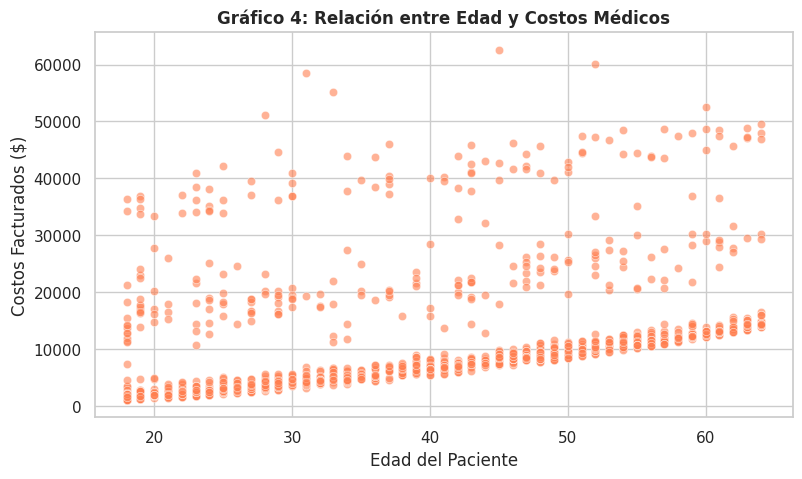

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.6, color='coral')

plt.title('Gráfico 4: Relación entre Edad y Costos Médicos', fontsize=12, fontweight='bold')
plt.xlabel('Edad del Paciente')
plt.ylabel('Costos Facturados ($)')
plt.show()

Gráfico 5: Dispersión de IMC vs. Costos por Estado de Fumador

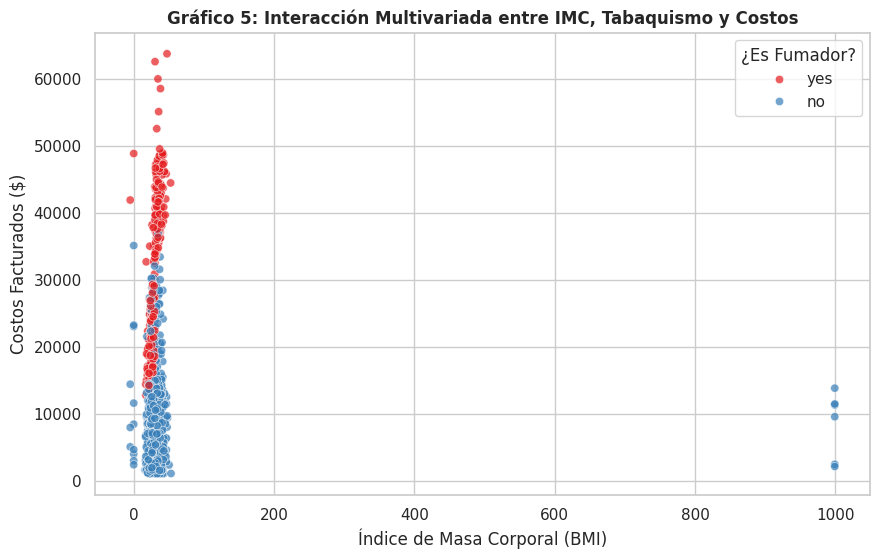

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)

plt.title('Gráfico 5: Interacción Multivariada entre IMC, Tabaquismo y Costos', fontsize=12, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (BMI)')
plt.ylabel('Costos Facturados ($)')
plt.legend(title='¿Es Fumador?')
plt.show()